# 03 — HMPNet y pooling Haar
Control **exploratorio HIGH** pareado: HMPNet con pooling Haar frente al mismo MPNN sin pooling. Son tres semillas y checkpoints elegidos por AUC en VAL; por lo tanto esto es evidencia de desarrollo, no test ni confirmación.

In [1]:
from pathlib import Path
import hashlib, json, tomllib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

ROOT = globals().get('ROOT') or next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'notebooks/evidencia.toml').is_file()), None)
if ROOT is None: raise RuntimeError('No se encontró notebooks/evidencia.toml.')
E = tomllib.loads((ROOT / 'notebooks/evidencia.toml').read_text())['hmp_high_control']
def ep(name): return ROOT / Path(E[name])
def sha256(path): return hashlib.sha256(path.read_bytes()).hexdigest()
if sha256(ep('report')) != E['report_sha256'] or sha256(ep('integrity')) != E['integrity_sha256']: raise ValueError('Raíz de evidencia HMP incompatible con evidencia.toml.')
report, integrity = json.loads(ep('report').read_text()), json.loads(ep('integrity').read_text())
if report['status'] != 'review_ready' or report['scope'] != 'exploratory_development_only' or report['test_opened'] or not report['validation_accessed_after_freeze'] or report['validation_accessed_before_freeze']: raise ValueError('Semántica del control HMP inválida.')
if report['seeds'] != [11, 23, 37] or set(report['variants']) != {'hmp_haar_v1', 'hmp_nohaar_v1'} or len(report['results']) != 6: raise ValueError('El control requiere 2 variantes × 3 semillas.')
output_root = ep('report').parent; score_frames, fit_reports = {}, {}
for result in report['results']:
    key = (result['variant_id'], result['seed']); fit_report_path = output_root / result['fit_report']
    if integrity.get(str(fit_report_path.relative_to(output_root))) != sha256(fit_report_path) or result['fit_report_sha256'] != sha256(fit_report_path): raise ValueError(f'Hash inválido para {key}.')
    fit_report = json.loads(fit_report_path.read_text()); score_path = fit_report_path.parent / fit_report['validation_scores_file']; companion_path = fit_report_path.parent / result['companion_coverage']['companion_scores_file']
    for path in (score_path, companion_path):
        if integrity.get(str(path.relative_to(output_root))) != sha256(path): raise ValueError(f'Hash inválido: {path.name}.')
    fit_reports[key] = fit_report; score_frames[key] = pd.read_csv(score_path)
template = score_frames[('hmp_haar_v1', 11)]
for key, frame in score_frames.items():
    if not frame.candidate_id.astype(str).equals(template.candidate_id.astype(str)) or not frame.global_event_id.astype(str).equals(template.global_event_id.astype(str)) or not frame.is_b.equals(template.is_b): raise ValueError(f'Cohorte no pareada: {key}.')
print({'fits': len(report['results']), 'validation_jets': len(template), 'validation_events': template.global_event_id.nunique(), 'seeds': report['seeds'], 'scope': report['scope'], 'test_opened': report['test_opened']})

{'fits': 6, 'validation_jets': 806, 'validation_events': 679, 'seeds': [11, 23, 37], 'scope': 'exploratory_development_only', 'test_opened': False}


In [2]:
metric_rows = [{'variante': item['variant_id'], 'seed': item['seed'], 'AUC ROC': item['roc_auc'], 'average precision': item['average_precision']} for item in report['results']]
metrics = pd.DataFrame(metric_rows); metric_summary = metrics.groupby('variante').agg(AUC_media=('AUC ROC', 'mean'), AUC_DE=('AUC ROC', 'std'), AP_media=('average precision', 'mean'), AP_DE=('average precision', 'std'))
paired = report['paired_comparison']; paired_table = pd.DataFrame([{'métrica': name, **values} for name, values in (('Δ AUC Haar−sin Haar', paired['roc_auc_delta_haar_minus_nohaar']), ('Δ AP Haar−sin Haar', paired['average_precision_delta_haar_minus_nohaar']))]).set_index('métrica')
display(metrics.set_index(['variante', 'seed']).style.format('{:.6f}')); display(metric_summary.style.format('{:.6f}')); display(paired_table.style.format({'estimate': '{:+.6f}', 'seed_std': '{:.6f}', 'lower95': '{:+.6f}', 'upper95': '{:+.6f}'}))
print('IC95: bootstrap pareado de 1.000 réplicas por evento completo sobre la VAL HIGH fija; no es p-value ni prueba confirmatoria.')

,AUC_media,AUC_DE,AP_media,AP_DE
variante,,,,
hmp_haar_v1,0.958723,0.002321,0.976586,0.001379
hmp_nohaar_v1,0.960166,0.001862,0.978040,0.001120


,estimate,lower95,seed_std,upper95,valid_replicates
métrica,,,,,
Δ AUC Haar−sin Haar,-0.001443,-0.004872,0.003669,+0.001978,1000
Δ AP Haar−sin Haar,-0.001453,-0.004240,0.002343,+0.000924,1000


IC95: bootstrap pareado de 1.000 réplicas por evento completo sobre la VAL HIGH fija; no es p-value ni prueba confirmatoria.


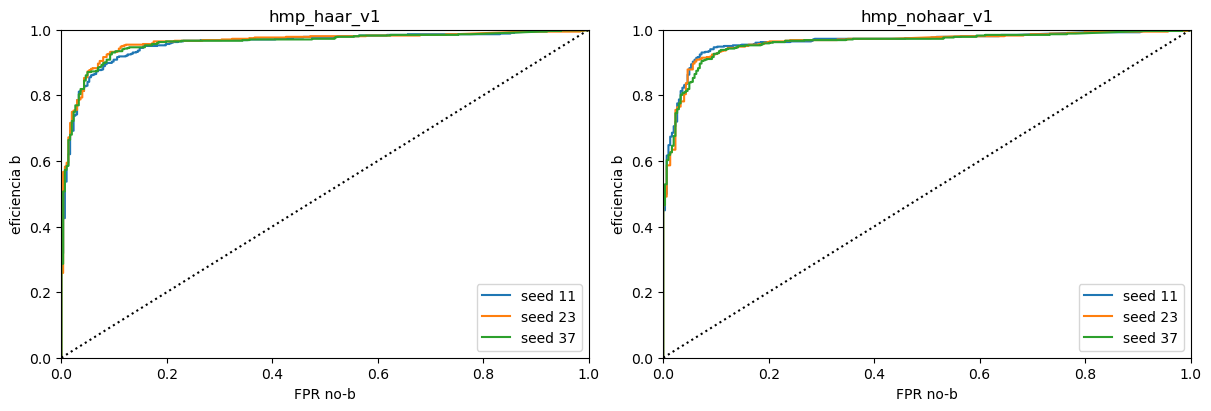

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for axis, variant in zip(axes, ('hmp_haar_v1', 'hmp_nohaar_v1'), strict=True):
    for seed in report['seeds']:
        frame = score_frames[(variant, seed)]; fpr, tpr, _ = roc_curve(frame.is_b, frame.score); axis.plot(fpr, tpr, label=f'seed {seed}')
    axis.plot([0, 1], [0, 1], ':', color='black'); axis.set(title=variant, xlabel='FPR no-b', ylabel='eficiencia b', xlim=(0, 1), ylim=(0, 1)); axis.legend()
plt.show(); plt.close(fig)

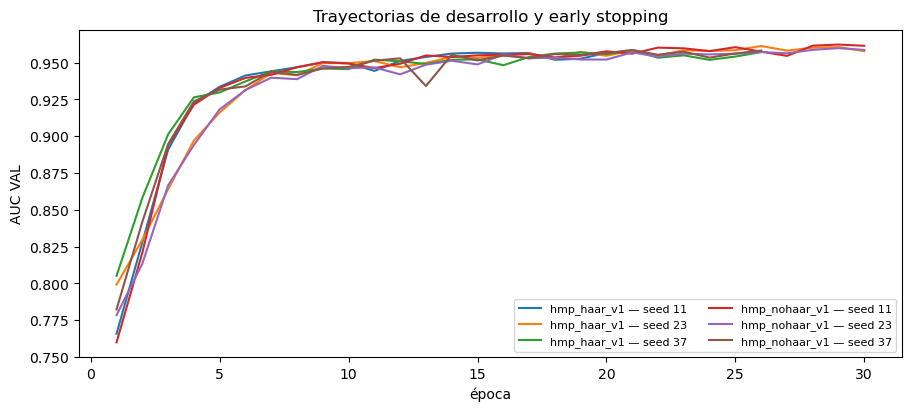

VAL eligió los checkpoints: estas curvas NO representan una evaluación holdout intacta.


In [4]:
fig, axis = plt.subplots(figsize=(9, 4), constrained_layout=True); history_rows = []
for (variant, seed), fit_report in fit_reports.items():
    history = pd.DataFrame(fit_report['history']); axis.plot(history.epoch + 1, history.validation_auc, label=f'{variant} — seed {seed}')
    best = history.loc[history.validation_auc.idxmax()]; history_rows.append({'variante': variant, 'seed': seed, 'épocas ejecutadas': len(history), 'checkpoint elegido': int(best.epoch) + 1, 'AUC elegida en VAL': best.validation_auc})
axis.set(xlabel='época', ylabel='AUC VAL', title='Trayectorias de desarrollo y early stopping'); axis.legend(fontsize=8, ncol=2); plt.show(); plt.close(fig)
display(pd.DataFrame(history_rows).set_index(['variante', 'seed']).style.format({'AUC elegida en VAL': '{:.6f}'})); print('VAL eligió los checkpoints: estas curvas NO representan una evaluación holdout intacta.')

In [5]:
coverage_rows, wp_rows = [], []
for item in report['results']:
    key = (item['variant_id'], item['seed']); coverage = item['companion_coverage']; metrics_wp = fit_reports[key]['validation']['object_metrics']
    coverage_rows.append({'variante': key[0], 'seed': key[1], 'companion jets': coverage['companion_jets'], 'eventos companion': coverage['companion_events'], 'unknown': coverage['unknown_jets'], 'unknown seleccionados WP70': coverage['selected_unknown_jets_at_known_truth_wp70'], 'zero-track total': coverage['zero_track_jets_all_truth_states'], 'zero-track unknown': coverage['zero_track_unknown_jets'], 'tracks retenidos': coverage['graph_policy']['retained_track_fraction'], 'jets truncados': coverage['graph_policy']['truncated_jets']})
    wp_rows.append({'variante': key[0], 'seed': key[1], 'eficiencia b': metrics_wp['b_efficiency'], 'pureza b': metrics_wp['b_purity'], 'denominador c': metrics_wp['c_mistag_denominator'], 'denominador light': metrics_wp['g_mistag_denominator'] + metrics_wp['uds_mistag_denominator']})
display(pd.DataFrame(coverage_rows).set_index(['variante', 'seed']).style.format({'tracks retenidos': '{:.1%}'})); display(pd.DataFrame(wp_rows).set_index(['variante', 'seed']).style.format({'eficiencia b': '{:.1%}', 'pureza b': '{:.1%}'}))
print('Se scorearon eventos unknown-only; unknown queda fuera de métricas truth. Los jets zero-track se conservaron y no se fabricaron tracks.')

Se scorearon eventos unknown-only; unknown queda fuera de métricas truth. Los jets zero-track se conservaron y no se fabricaron tracks.


## Ajuste HIGH sin Haar — selección sólo con TRAIN
La búsqueda usa tres folds agrupados por evento dentro de TRAIN. Los dos finalistas se congelan antes de abrir VAL; VAL cuantifica incertidumbre pero **no puede cambiar el ranking**.

HPO HIGH


,candidate_id,mean_train_cv_auc,train_cv_auc_std,mean_train_cv_ap,parameter_count,rank
0,h40_s3_r21_lr1e3,0.951377,0.008413,0.975721,22441,1
1,h40_s2_r21_lr1e3,0.949897,0.010230,0.975035,15121,2
2,h40_s1_r21_lr1e3,0.947285,0.006782,0.974475,7801,3
3,h24_s2_r15_lr1e3,0.947046,0.008150,0.974477,5713,4
4,h64_s2_r21_lr1e3,0.946250,0.019510,0.968900,36481,5
5,h40_s2_r21_lr3e4,0.927213,0.009099,0.962485,15121,6


{'región': 'high', 'primario TRAIN-CV': 'h40_s3_r21_lr1e3', 'sensibilidad': 'h40_s2_r21_lr1e3', 'delta_auc_val_primario_menos_sensibilidad': 0.0008901486570127201, 'IC95': [-0.0020102111097050753, 0.0036202518163566985], 'train_events': 3224, 'test_opened': False}
HPO LOW


,candidate_id,mean_train_cv_auc,train_cv_auc_std,mean_train_cv_ap,parameter_count,rank
0,h64_s2_r21_lr1e3,0.892495,0.004246,0.820636,36481,1
1,h40_s3_r21_lr1e3,0.890839,0.002520,0.813625,22441,2
2,h24_s2_r15_lr1e3,0.890379,0.006101,0.809409,5713,3
3,h40_s2_r21_lr1e3,0.890268,0.003129,0.815785,15121,4
4,h40_s1_r21_lr1e3,0.889880,0.003563,0.811346,7801,5
5,h40_s2_r21_lr3e4,0.874416,0.003899,0.780068,15121,6


{'región': 'low', 'primario TRAIN-CV': 'h64_s2_r21_lr1e3', 'sensibilidad': 'h40_s3_r21_lr1e3', 'delta_auc_val_primario_menos_sensibilidad': -0.001954968678879565, 'IC95': [-0.0027628655197017814, -0.0011375393579888982], 'train_events': 6000, 'test_opened': False}


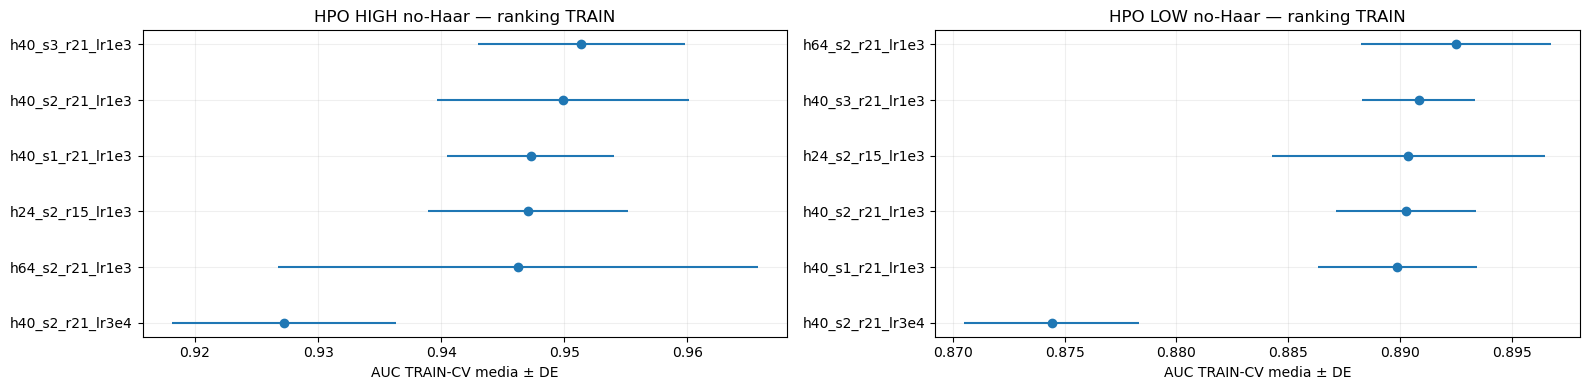

In [6]:
import sys
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from ml.hmp_evidence import load_registered_regions
hpo_regions = load_registered_regions(ROOT, tomllib.loads((ROOT / 'notebooks/evidencia.toml').read_text()))
high_hpo = hpo_regions['high']; hpo_report = high_hpo['report']; hpo_closure = high_hpo['closure']; fold_cohorts = high_hpo['fold_cohorts']; selection_freeze = high_hpo['selection_freeze']; hpo_summary = high_hpo['candidate_summary']; hpo_folds = high_hpo['train_folds']; hpo_wp70 = high_hpo['wp70'].rename(columns={'candidate_id': 'candidato'})
delta = hpo_report['finalist_paired_comparison']['roc_auc_delta_primary_minus_sensitivity']
for region, bundle in hpo_regions.items():
    comparison = bundle['report']['finalist_paired_comparison']['roc_auc_delta_primary_minus_sensitivity']
    print(f'HPO {region.upper()}'); display(bundle['candidate_summary'].style.format({'mean_train_cv_auc': '{:.6f}', 'train_cv_auc_std': '{:.6f}', 'mean_train_cv_ap': '{:.6f}'})); display(bundle['wp70'].set_index(['candidate_id', 'seed']).style.format('{:.4f}'))
    print({'región': region, 'primario TRAIN-CV': bundle['report']['primary_finalist'], 'sensibilidad': bundle['report']['sensitivity_finalist'], 'delta_auc_val_primario_menos_sensibilidad': comparison['estimate'], 'IC95': [comparison['lower95'], comparison['upper95']], 'train_events': bundle['fold_cohorts']['train_events'], 'test_opened': bundle['report']['test_opened']})
fig, axes = plt.subplots(1, len(hpo_regions), figsize=(8 * len(hpo_regions), 4), squeeze=False)
for ax, (region, bundle) in zip(axes[0], hpo_regions.items()):
    ordered = bundle['candidate_summary'].sort_values('mean_train_cv_auc'); ax.errorbar(ordered.mean_train_cv_auc, ordered.candidate_id, xerr=ordered.train_cv_auc_std, fmt='o'); ax.set(xlabel='AUC TRAIN-CV media ± DE', title=f'HPO {region.upper()} no-Haar — ranking TRAIN'); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

## Decisión del gate HIGH
El pooling Haar **no mostró un beneficio demostrado** en este control HIGH exploratorio: los intervalos pareados de ΔAUC y ΔAP incluyen cero y los estimadores centrales son levemente negativos. Esto es compatible con ausencia de mejora detectable, no una prueba formal de equivalencia.

Después del ajuste HIGH sin Haar, `h40_s3_r21_lr1e3` queda congelado como rank-1 HIGH por TRAIN-CV. LOW reevalúa el vecindario con su propio TRAIN y selecciona `h64_s2_r21_lr1e3`; el candidato HIGH-derived `h40_s3_r21_lr1e3` queda segundo. En VAL LOW, el primario TRAIN-CV es inferior en promedio (ΔAUC primario−sensibilidad = −0,001955; IC95 [−0,002763, −0,001138]), pero **VAL no rerankea** por contrato. Esto muestra dependencia regional y no una validación simple de transferencia. Ambos resultados son exploratorios, usan caps/provenance explícitos y no abrieron TEST.